# region_dealias 验证（官方示例数据）

流程：
1. 从官方 MDV 生成固定 CfRadial，再转为极坐标体扫网格输入；
2. 对齐官方示例：不做探空参考速度锚定（`ref_vel_field=None`）；
3. 对比官方 `dealias_region_based` 与迁移函数/插件/CLI；
4. 可选完成经纬网格重映射与 cinrad 风格图。


## 0. 环境与工具函数



In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import pyart
from IPython.display import display
from matplotlib.font_manager import FontProperties
from cinrad_data import get_font_path
from cinrad.visualize.utils import cmap_plot, norm_plot, prodname, unit

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parents[1]  #项目根目录
TEST_DATA_DIR = NOTEBOOK_DIR.parent / "test_data" / "region_dealias"  # 测试数据路径
CLI_INPUT_DIR = TEST_DATA_DIR / "cli_input"  # 输入数据目录
CLI_OUTPUT_DIR = TEST_DATA_DIR / "cli_output"  #输出结果目录
CLI_INPUT_DIR.mkdir(parents=True, exist_ok=True)
CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from radar_wind_dealiasing import GridGateFilter, RegionDealiasPlugin, dealias_region_based
from radar_wind_dealiasing.cli.polar_volume_main import (
    pyart_radar_to_polar_volume,
    read_polar_volume,
    validate_polar_volume,
)
from radar_wind_dealiasing.src.utils._geo_remap import (
    attach_gate_lonlat,
    mask_outside_radar_coverage,
    remap_gate_data_to_latlon_grid,
)

MDV_FILE = TEST_DATA_DIR / "095636.mdv"
CFRADIAL_FIXED_FILE = CLI_INPUT_DIR / "radar_fixed.cfradial.nc"
SWEEP_INDEX = 0

# CLI 样例只落盘单个扫描层，控制仓库体积
VELOCITY_SWEEP_PATH = CLI_INPUT_DIR / f"velocity_sweep{SWEEP_INDEX}.nc"
GATEFILTER_MASK_PATH = (
    CLI_INPUT_DIR / f"grid_gatefilter_mask_sweep{SWEEP_INDEX}.npy"
)

d:\workspace\pyart_nimm\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



工具函数

In [2]:
def sanitize_field_for_plot(arr, attrs=None):
    """清洗绘图用物理量：掩码/填充值转 NaN，并屏蔽绝对值过大的离群点。"""
    fill_value = None if attrs is None else attrs.get("_FillValue")
    missing_value = None if attrs is None else attrs.get("missing_value")
    if np.ma.isMaskedArray(arr):
        out = np.asarray(arr.data, dtype=np.float32).copy()
        out[np.ma.getmaskarray(arr)] = np.nan
    else:
        out = np.asarray(arr, dtype=np.float32).copy()
    for value in (fill_value, missing_value):
        try:
            fill = float(value)
        except (TypeError, ValueError):
            continue
        if np.isfinite(fill):
            out[np.isclose(out, fill, rtol=0.0, atol=0.0)] = np.nan
    out[np.abs(out) > 1e3] = np.nan
    return out


def save_griddata(grd, path):
    """将 meteva 六维网格写出为压缩 NetCDF。"""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    name = grd.name or "data"
    grd.to_dataset(name=name).to_netcdf(
        path,
        encoding={name: {"dtype": "float32", "zlib": True, "complevel": 1}},
    )


def plot_compare(field_a, field_b, lon2d, lat2d, title_a, title_b, title_diff):
    """三连对比图：A、B 与差值（速度场用 cinrad VEL 色标）。"""
    vel_kw = {"cmap": cmap_plot["VEL"], "norm": norm_plot["VEL"]}
    diff = field_b - field_a
    valid = np.isfinite(field_a) & np.isfinite(field_b)
    mae = float(np.nanmean(np.abs(diff[valid]))) if np.any(valid) else np.nan
    max_abs = float(np.nanmax(np.abs(diff[valid]))) if np.any(valid) else np.nan
    dlim = (
        np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 99)
        if np.any(np.isfinite(diff))
        else 1.0
    )
    dlim = float(dlim) if dlim > 0 else 1.0

    fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
    panels = (
        (axes[0], field_a, title_a, vel_kw),
        (axes[1], field_b, title_b, vel_kw),
        (
            axes[2],
            diff,
            f"{title_diff}\nMAE={mae:.6f}, MaxAbs={max_abs:.6f}",
            {"cmap": "coolwarm", "vmin": -dlim, "vmax": dlim},
        ),
    )
    for ax, data, title, kw in panels:
        im = ax.pcolormesh(lon2d, lat2d, data, shading="auto", **kw)
        ax.set_title(title, fontproperties=FontProperties(fname=get_font_path()))
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        plt.colorbar(im, ax=ax)
    plt.show()


def plot_lonlat_field(data, lon, lat, field_name, title, *, figsize=(8.0, 6.5)):
    """按 cinrad 产品色标绘制经纬平面场（补充单幅展示）。"""
    font = FontProperties(fname=get_font_path())
    dtype = field_name.strip().upper()
    if dtype not in norm_plot:
        raise ValueError(f"Unknown cinrad field: {field_name}")

    values = np.asarray(data, dtype=np.float32)
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.asarray(lat, dtype=np.float64)
    if lon.ndim == 1 and lat.ndim == 1:
        lon_plot, lat_plot = np.meshgrid(lon, lat)
    else:
        lon_plot, lat_plot = lon, lat

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    im = ax.pcolormesh(
        lon_plot,
        lat_plot,
        values,
        cmap=cmap_plot[dtype],
        norm=norm_plot[dtype],
        shading="auto",
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", linewidth=0.6, color="0.45", alpha=0.55)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    unit_label = unit.get(dtype, "")
    name = prodname.get(dtype, dtype)
    cbar.set_label(
        f"{name} ({unit_label})" if unit_label else name,
        fontproperties=font,
    )
    for label in cbar.ax.get_yticklabels():
        label.set_fontproperties(font)

    fig.suptitle(title, fontproperties=font)
    return fig


print("MDV:", MDV_FILE.exists())
print("cli_input:", CLI_INPUT_DIR)
print("cli_output:", CLI_OUTPUT_DIR)


MDV: True
cli_input: d:\workspace\pyart_nimm\region_dealias\test_data\region_dealias\cli_input
cli_output: d:\workspace\pyart_nimm\region_dealias\test_data\region_dealias\cli_output


## 1. 准备官方数据与极坐标体扫输入

- 若 `cli_input/` 中已有固定 CfRadial 与单层 `velocity_sweep0.nc`，直接复用；缺失时自动生成。
- 验证与 CLI **回写样例仅保留单个扫描层**，避免大体扫文件进入仓库。
- 反射率只在内存中转换，用于构建 gatefilter，不再单独写出。


In [3]:
if not CFRADIAL_FIXED_FILE.exists():
    radar_mdv = pyart.io.read_mdv(str(MDV_FILE))
    pyart.io.write_cfradial(str(CFRADIAL_FIXED_FILE), radar_mdv)
    print("generated:", CFRADIAL_FIXED_FILE)

radar = pyart.io.read_cfradial(str(CFRADIAL_FIXED_FILE))
print("fields:", list(radar.fields)[:12])
print("nsweeps / nrays / ngates:", radar.nsweeps, radar.nrays, radar.ngates)


fields: ['specific_differential_phase', 'normalized_coherent_power', 'velocity', 'cross_correlation_ratio', 'reflectivity', 'differential_phase', 'spectrum_width', 'differential_reflectivity']
nsweeps / nrays / ngates: 17 6120 983


In [4]:
radar_sweep = radar.extract_sweeps([SWEEP_INDEX])

need_regenerate = not VELOCITY_SWEEP_PATH.exists()
if need_regenerate:
    velocity_grid = pyart_radar_to_polar_volume(radar_sweep, "velocity")
    validate_polar_volume(velocity_grid, require_geolocation=True)
    save_griddata(velocity_grid, VELOCITY_SWEEP_PATH)
    print("regenerated single-sweep velocity input")
else:
    velocity_grid = read_polar_volume(
        VELOCITY_SWEEP_PATH,
        value_name="velocity",
    )
    print("reuse existing single-sweep velocity input")

# 反射率仅用于构建 gatefilter，不落盘
refl_grid = pyart_radar_to_polar_volume(radar_sweep, "reflectivity")
validate_polar_volume(refl_grid, require_geolocation=True)

lat2d, lon2d, _ = radar.get_gate_lat_lon_alt(SWEEP_INDEX)
lat2d = np.asarray(lat2d, dtype=np.float64)
lon2d = np.asarray(lon2d, dtype=np.float64)
radar_lon = float(radar.longitude["data"][0])
radar_lat = float(radar.latitude["data"][0])

print("sweep_index:", SWEEP_INDEX)
print("sweep shape:", velocity_grid.shape)


reuse existing single-sweep velocity input
sweep_index: 0
sweep shape: (1, 1, 1, 1, 360, 983)


## 2. 官方 vs 迁移核心算法（门点经纬度）

对齐官方示例过滤：`exclude_transition` + `exclude_invalid(velocity/reflectivity)` +
`exclude_outside(reflectivity, 0, 80)`。


official / migrated shape: (360, 983) (360, 983)


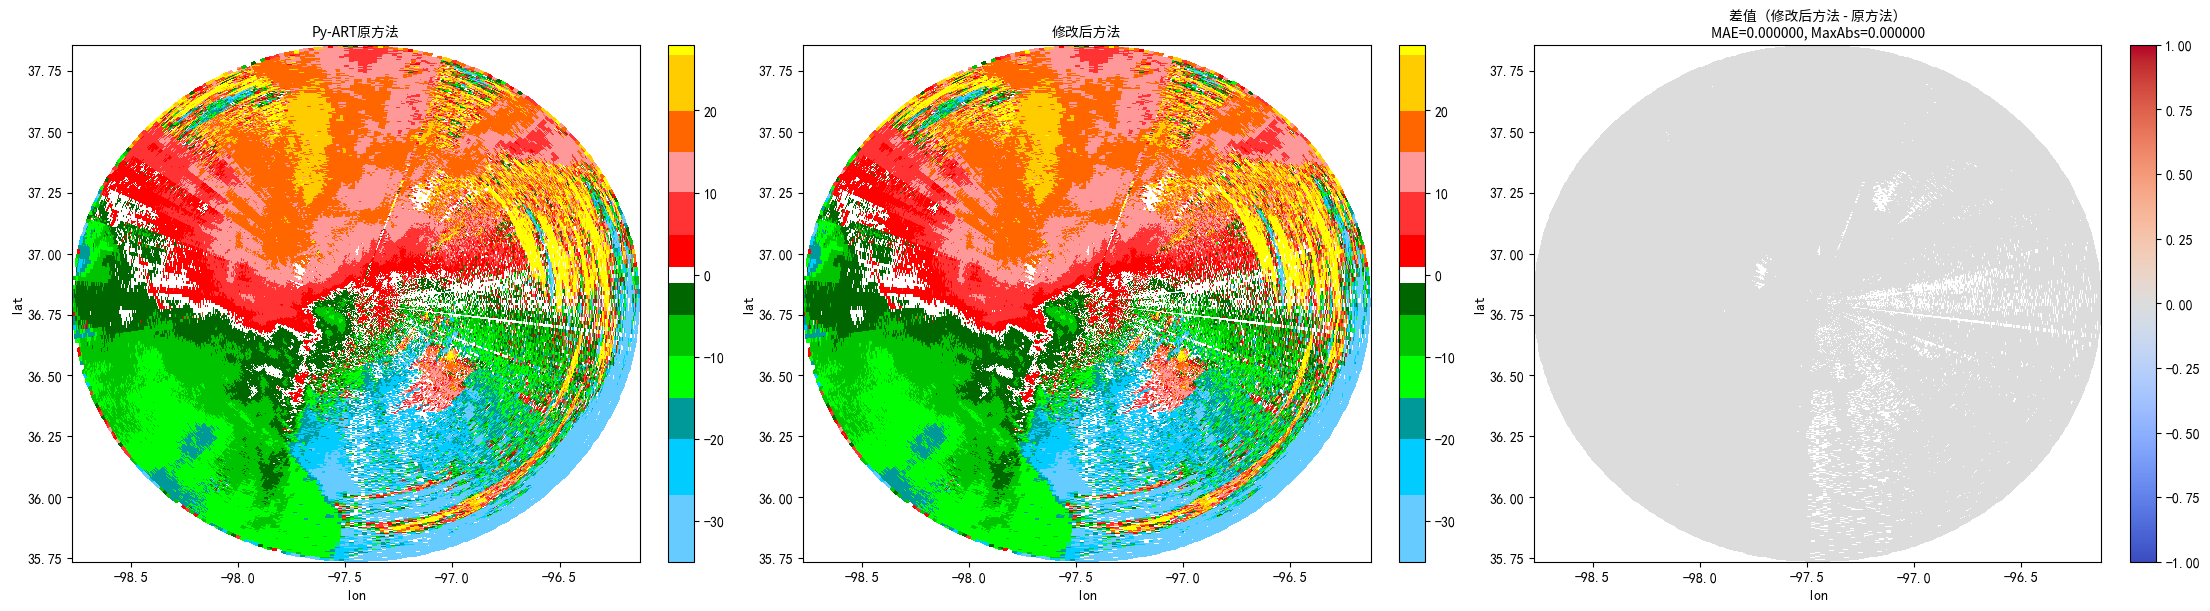

In [5]:
# 官方对比也限定到同一扫描层，与回写样例一致
gatefilter = pyart.filters.GateFilter(radar_sweep)
gatefilter.exclude_transition()
gatefilter.exclude_invalid("velocity")
gatefilter.exclude_invalid("reflectivity")
gatefilter.exclude_outside("reflectivity", 0, 80)

official = pyart.correct.dealias_region_based(
    radar_sweep,
    gatefilter=gatefilter,
    vel_field="velocity",
    corr_vel_field="corrected_velocity_official",
)
official_2d = sanitize_field_for_plot(official["data"], attrs=official)

plugin_gatefilter = GridGateFilter(velocity_grid)
plugin_gatefilter.exclude_transition()
plugin_gatefilter.exclude_invalid(velocity_grid)
plugin_gatefilter.exclude_invalid(refl_grid)
plugin_gatefilter.exclude_outside(refl_grid, 0, 80)
np.save(GATEFILTER_MASK_PATH, plugin_gatefilter.gate_excluded)

migrated_grid = dealias_region_based(
    velocity=velocity_grid,
    gatefilter=plugin_gatefilter,
)
migrated_2d = sanitize_field_for_plot(
    migrated_grid.values[0, 0, 0, 0],
    attrs=migrated_grid.attrs,
)
velocity_2d = sanitize_field_for_plot(
    velocity_grid.values[0, 0, 0, 0],
    attrs=velocity_grid.attrs,
)

print("official / migrated shape:", official_2d.shape, migrated_2d.shape)
plot_compare(
    official_2d,
    migrated_2d,
    lon2d,
    lat2d,
    "Py-ART原方法",
    "修改后方法",
    "差值（修改后方法 - 原方法）",
)


## 3. 插件经纬重映射对比

启用 `auto_remap_to_latlon=True` 后，结果由单层极坐标变为规则经纬网格。主要形式特点：

- `grid_axis_type="latlon"`，`lat` / `lon` 为真实经纬度轴（度），不再是方位角 × 径距。
- `level` 维对应该扫描层的固定仰角（`fixed_angle`），并有 `level_coordinate="elevation_deg"`。
- 仍为六维容器：`member, level, time, dtime, lat, lon`。

下方先做插件重映射，再把官方单层结果按同一套门点经纬度插到同一目标网格后做数值对比。


geo level: 0.75


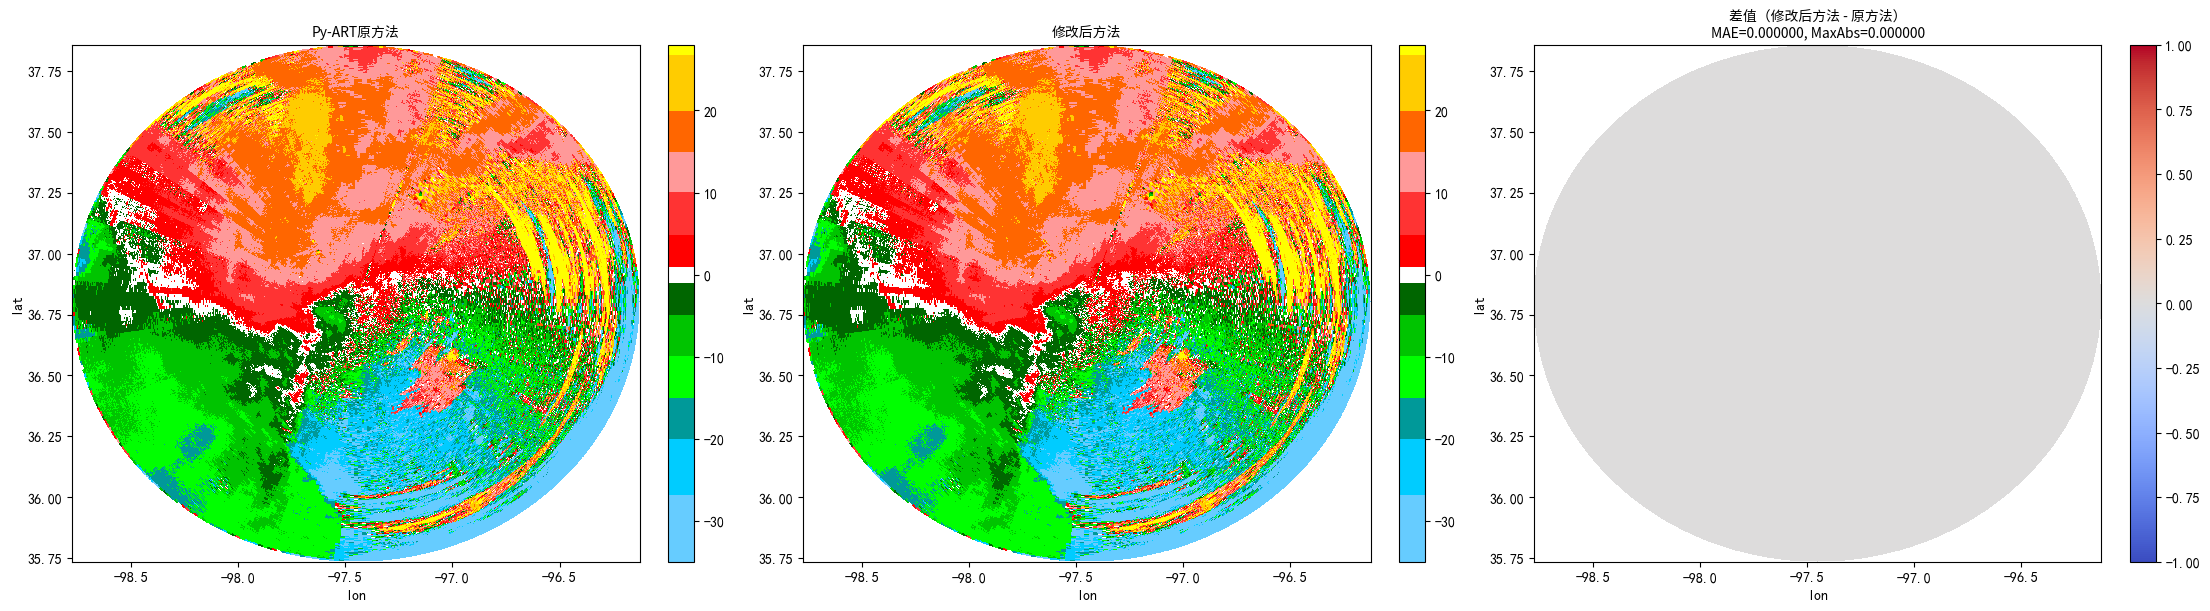

In [6]:
geo_plugin = RegionDealiasPlugin(
    gatefilter=plugin_gatefilter,
    radar_lon=radar_lon,
    radar_lat=radar_lat,
    auto_remap_to_latlon=True,
    geo_resolution_deg=0.001,
    data_name="corrected_velocity_geo",
)
geo_grid = geo_plugin.process(velocity=velocity_grid)
geo_level = geo_grid.isel(level=0)
geo_2d = sanitize_field_for_plot(geo_level.values.squeeze(), attrs=geo_grid.attrs)
geo_lon = np.asarray(geo_grid.lon.values, dtype=np.float64)
geo_lat = np.asarray(geo_grid.lat.values, dtype=np.float64)
geo_lon2d, geo_lat2d = np.meshgrid(geo_lon, geo_lat)

# 官方侧手动重映射：使用同一套门点经纬度（attach_gate_lonlat），
# 不能改用 radar.get_gate_lat_lon_alt（坐标系不同会放大 MAE）。
attached_for_compare = attach_gate_lonlat(
    velocity_grid,
    radar_lon=radar_lon,
    radar_lat=radar_lat,
)
sweep_gate_lon = np.asarray(
    attached_for_compare.coords["gate_lon"].values,
    dtype=np.float64,
)
sweep_gate_lat = np.asarray(
    attached_for_compare.coords["gate_lat"].values,
    dtype=np.float64,
)

official_geo_values = remap_gate_data_to_latlon_grid(
    values=official_2d,
    gate_lon=sweep_gate_lon,
    gate_lat=sweep_gate_lat,
    target_lon=geo_lon,
    target_lat=geo_lat,
    method="nearest",
    fill_value=np.nan,
)
official_geo_values = mask_outside_radar_coverage(
    official_geo_values,
    target_lon=geo_lon,
    target_lat=geo_lat,
    radar_lon=radar_lon,
    radar_lat=radar_lat,
    gate_lon=sweep_gate_lon,
    gate_lat=sweep_gate_lat,
    fill_value=np.nan,
)
official_geo_2d = sanitize_field_for_plot(official_geo_values)

print("geo level:", float(geo_level.level.values))
plot_compare(
    official_geo_2d,
    geo_2d,
    geo_lon2d,
    geo_lat2d,
    "Py-ART原方法",
    "修改后方法",
    "差值（修改后方法 - 原方法）",
)


In [7]:
geo_grid

<xarray.DataArray 'corrected_velocity_geo' (member: 1, level: 1, time: 1,
                                            dtime: 1, lat: 2122, lon: 2649)> Size: 22MB
array([[[[[[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
           [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
           [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
           ...,
           [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
           [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
           [-9999., -9999., -9999., ..., -9999., -9999., -9999.]]]]]],
      shape=(1, 1, 1, 1, 2122, 2649), dtype=float32)
Coordinates:
  * member   (member) <U5 20B 'radar'
  * level    (level) float64 8B 0.75
  * time     (time) datetime64[ns] 8B 2011-05-20T09:51:01
  * dtime    (dtime) int64 8B 0
  * lat      (lat) float64 17kB 35.74 35.74 35.74 35.74 ... 37.85 37.86 37.86
  * lon      (lon) float64 21kB -98.77 -98.77 -98.77 ... -96.13 -96.13 -96.13
Attributes: (12/18)
    grid_axis_type:           latlon
    polar_volume_convention:  ray_gate_v1
    sweep_start_ray_index:    0
    sweep_end_ray_index:      359
    nyquist_velocity:         16.524972915649414
    fixed_angle:              0.75
    ...                       ...
    long_name:                dealiased velocity
    standard_name:            radial_velocity_of_scatterers_away_from_instrument
    _FillValue:               -9999.0
    valid_min:                -148.72476196289062
    valid_max:                148.72476196289062
    level_coordinate:         elevation_deg

## 4. CLI 入口对比

调用 `radar_wind_dealiasing.cli.region_dealias.process`，按是否做经纬重映射分为两小节。


### 4.1 单层极坐标拓扑输出

读取单层速度与过滤掩码，不转换到经纬网格。


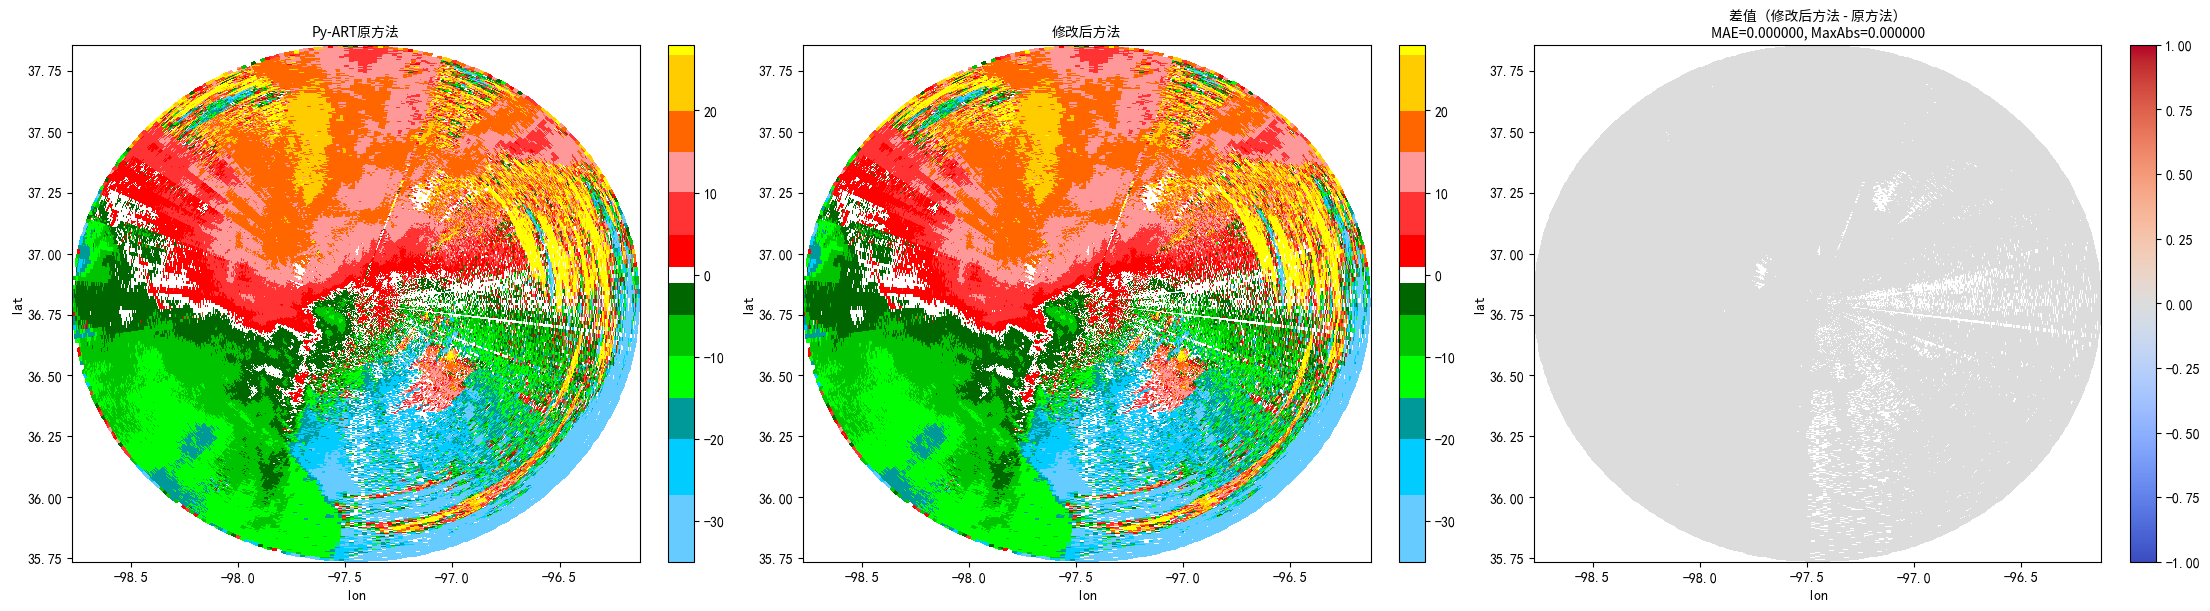

In [8]:
from radar_wind_dealiasing.cli.region_dealias import process

CLI_RESULT_FILE = CLI_OUTPUT_DIR / "region_dealias_cli.nc"

process(
    str(VELOCITY_SWEEP_PATH),
    gatefilter_path=str(GATEFILTER_MASK_PATH),
    data_name="corrected_velocity_cli",
    output_path=str(CLI_RESULT_FILE),
)

cli_grid = meb.read_griddata_from_nc(
    str(CLI_RESULT_FILE),
    value_name="corrected_velocity_cli",
)
cli_2d = sanitize_field_for_plot(
    cli_grid.values[0, 0, 0, 0],
    attrs=cli_grid.attrs,
)

plot_compare(
    official_2d,
    cli_2d,
    lon2d,
    lat2d,
    "Py-ART原方法",
    "修改后方法",
    "差值（修改后方法 - 原方法）",
)


### 4.2 经纬网格输出

`auto_remap_to_latlon=True`，结果为规则经纬网格。


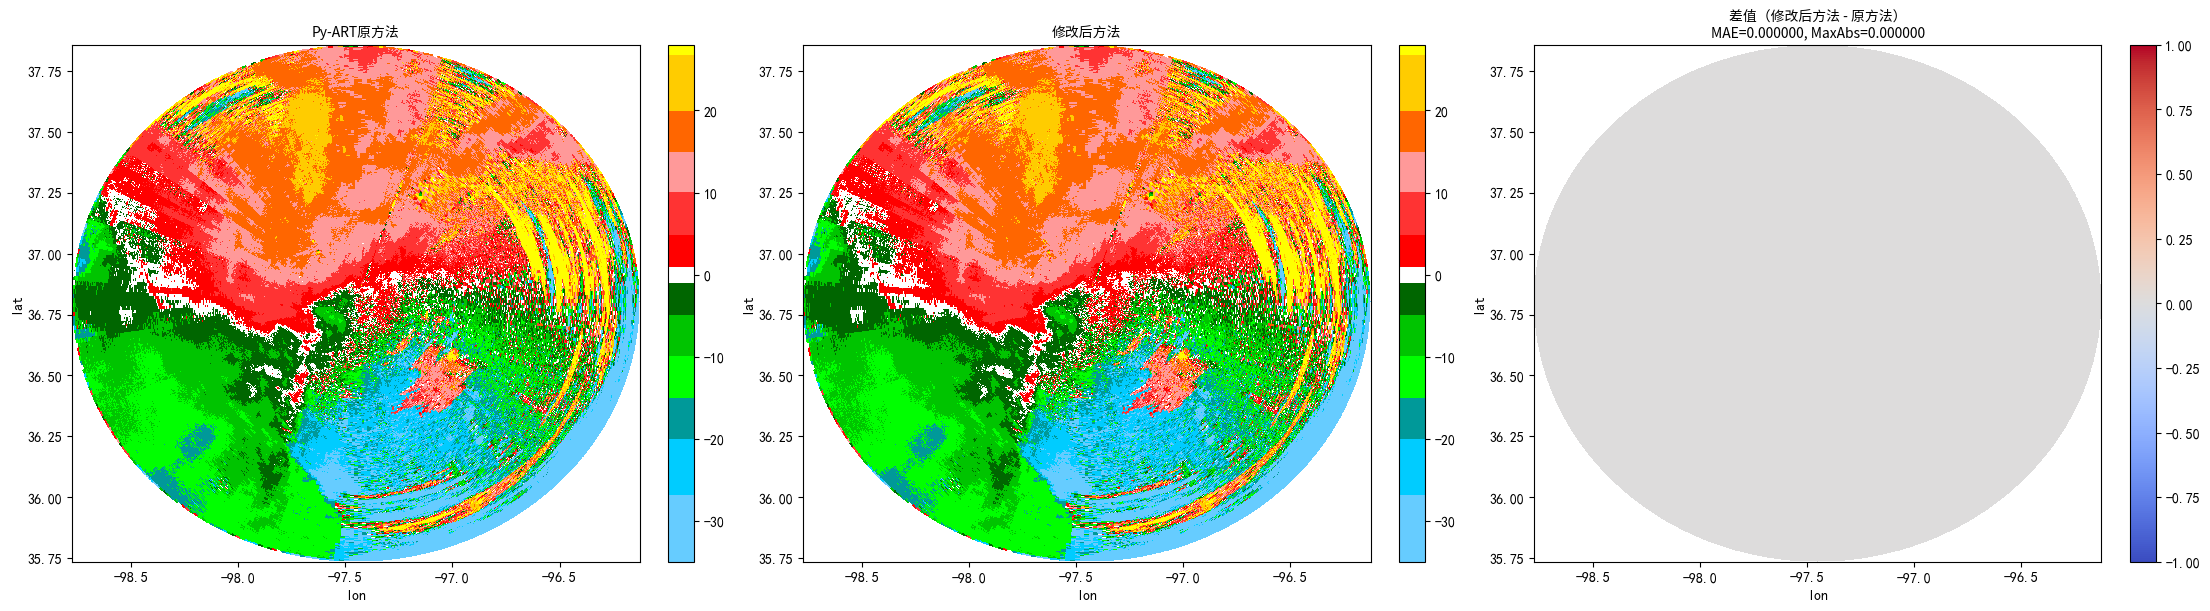

In [9]:
CLI_GEO_RESULT_FILE = CLI_OUTPUT_DIR / "region_dealias_cli_geo.nc"

process(
    str(VELOCITY_SWEEP_PATH),
    gatefilter_path=str(GATEFILTER_MASK_PATH),
    data_name="corrected_velocity_cli_geo",
    auto_remap_to_latlon=True,
    geo_resolution_deg=0.001,
    output_path=str(CLI_GEO_RESULT_FILE),
)

cli_geo_grid = meb.read_griddata_from_nc(
    str(CLI_GEO_RESULT_FILE),
    value_name="corrected_velocity_cli_geo",
)
cli_geo_level = cli_geo_grid.isel(level=0)
cli_geo_2d = sanitize_field_for_plot(
    cli_geo_level.values.squeeze(),
    attrs=cli_geo_grid.attrs,
)

plot_compare(
    official_geo_2d,
    cli_geo_2d,
    geo_lon2d,
    geo_lat2d,
    "Py-ART原方法",
    "修改后方法",
    "差值（修改后方法 - 原方法）",
)


## 5. 输入与退模糊结果展示

门点经纬度上的输入/退模糊场；经纬重映射结果已在第 3、4 节对比，此处不再重复。


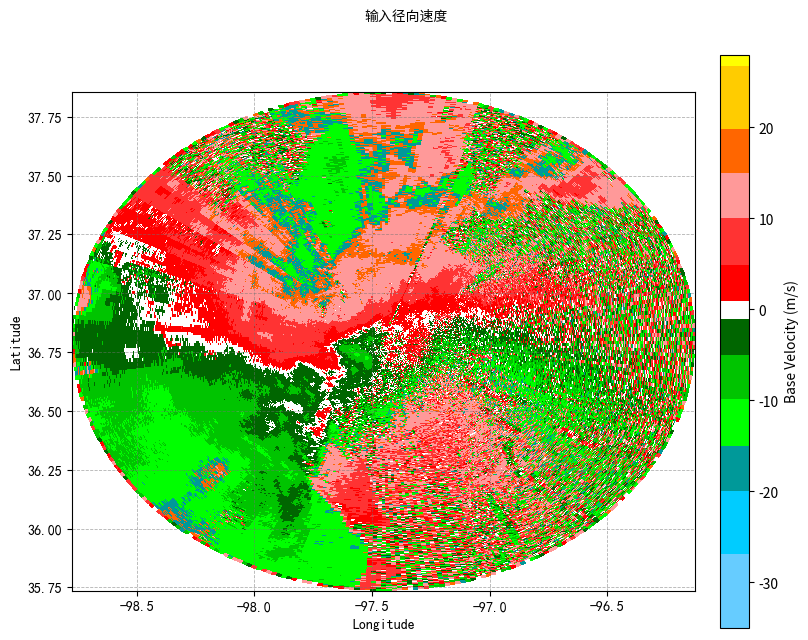

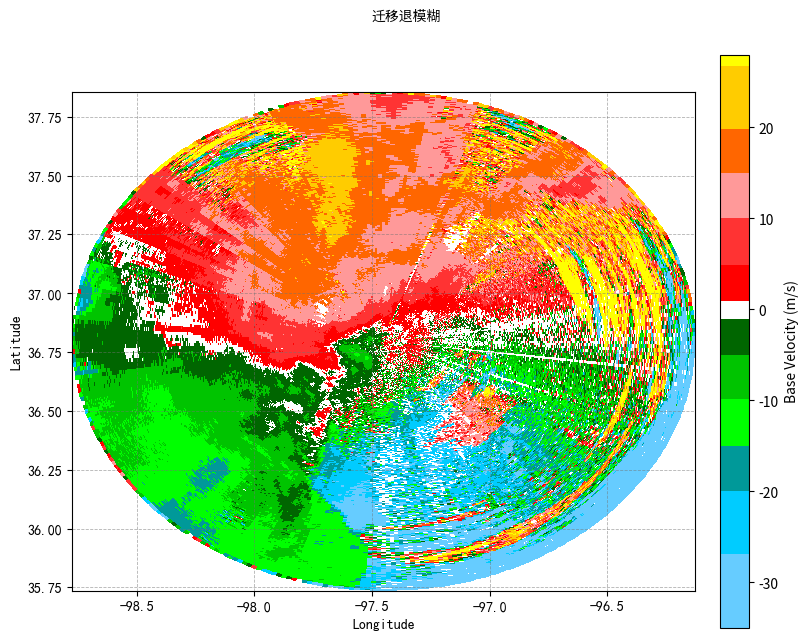

In [10]:
plot_specs = [
    (velocity_2d, lon2d, lat2d, "输入径向速度"),
    (migrated_2d, lon2d, lat2d, "迁移退模糊"),
]
for values, plot_lon, plot_lat, title in plot_specs:
    with plt.ioff():
        fig = plot_lonlat_field(values, plot_lon, plot_lat, "VEL", title)
    display(fig)
    plt.close(fig)


## 说明

- 算法支持完整体扫；验证样例与 CLI 回写仅保留 `SWEEP_INDEX` 对应的单层，控制仓库体积。
- `cli_input/velocity_sweep0.nc` 为单层极坐标速度输入。
- `cli_input/grid_gatefilter_mask_sweep0.npy` 为对应单层过滤掩码。
- 反射率等辅助场仅在 notebook 内存中用于构建 gatefilter，不再写出。
- `radar_fixed.cfradial.nc` / 源 MDV 体积很大，建议仅本地保留，不要提交到 GitHub。
